In [3]:
#Import Pandas and load dataset
import pandas as pd
df = pd.read_excel(r"C:\Users\nokwa\Downloads\Random.xlsx")
df.head(2)

,Dist_from_home,Purchase_price_ratio,Fraud Class
0,2,7,1
1,4,3,1


In [5]:
df.isnull().any()

Dist_from_home          False
Purchase_price_ratio    False
Fraud Class             False
dtype: bool

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Dist_from_home        40 non-null     int64
 1   Purchase_price_ratio  40 non-null     int64
 2   Fraud Class           40 non-null     int64
dtypes: int64(3)
memory usage: 1.1 KB


In [7]:
#Select features
x = df.drop(columns = 'Fraud Class')
y = df[['Fraud Class']]

In [8]:
#Split data into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [9]:
#Standardise/ normalise data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [10]:
#Create the KNN model
from sklearn.neighbors import KNeighborsClassifier
k = 8
knn = KNeighborsClassifier(n_neighbors = k)
knn

,n_neighbors,8
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
#Train the model
knn.fit(x_train, y_train)
knn

C:\Users\nokwa\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,8
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [12]:
#Test the model using the test set
predicted_fraud_class = knn.predict(x_test)

In [13]:
#Evaluate the model accuaracy
from sklearn.metrics import accuracy_score
acc_score = accuracy_score(y_test, predicted_fraud_class)
print(acc_score)

0.5


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

scaler = StandardScaler()
X = scaler.fit_transform(x)
y = y.values.ravel()
k_values = range(1, 31)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X, y, cv=5)
    scores.append(np.mean(score))


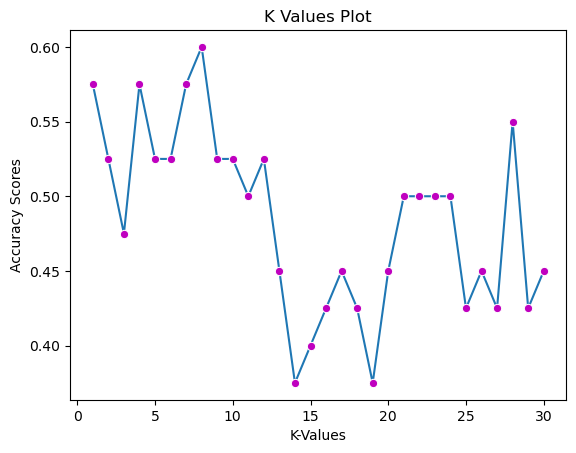

In [15]:
#Plot the scores on a line graph
from matplotlib import pyplot as plt
import seaborn as sb
sb.lineplot(x = k_values, y = scores, marker = 'o', markerfacecolor = 'm')
plt.title('K Values Plot')
plt.xlabel('K-Values')
plt.ylabel('Accuracy Scores')
plt.show()